In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from math import inf

In [2]:
#read the shapefile of the roads in Bangladesh, found in the cleaned WBSIM
gdf = gpd.read_file('gis/osm/roads.shp')

In [3]:
#read an csv of all intersection points
inter = pd.read_csv('intersections.csv')

In [4]:
#read the road information csv, foun in the cleaned WBSIM
roads = pd.read_csv('_roads3.csv')

In [5]:
relevant_roads = inter.road.unique()

In [8]:
#every intersection is shown twice in the intersection csv, these points need to be linked based on the shortest distance between the points.
inter['intersect'] = 0
for i in inter.index:
    if inter.loc[i,'intersect'] == 0:
        closest = 0
        totdist = inf
        index = 0
        for j in inter.index:
            if i != j:
                londiff = abs(inter.loc[i,'lon'] - inter.loc[j,'lon'])
                latdiff = abs(inter.loc[i,'lat']-inter.loc[j,'lat'])
                if londiff + latdiff < totdist:
                    totdist = londiff + latdiff
                    closest = inter.loc[j, 'id']
                    index = j
        inter.loc[i,'intersect'] = closest
        inter.loc[index,'intersect'] = inter.loc[i,'id']


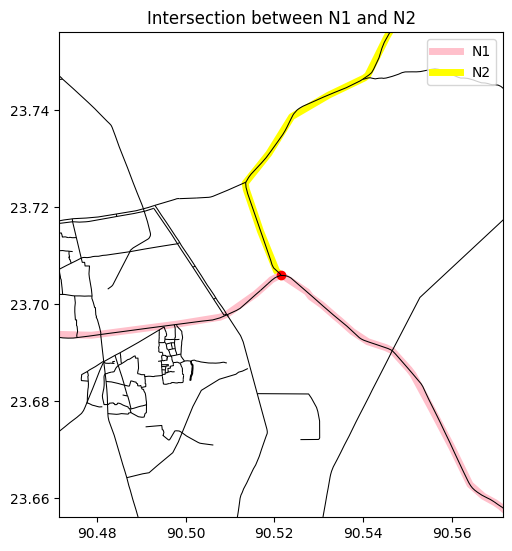

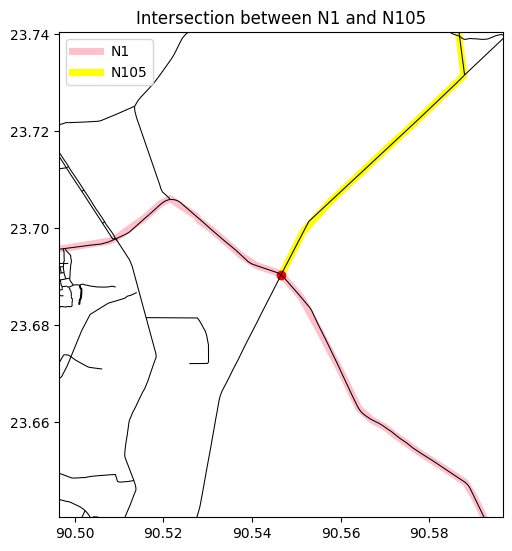

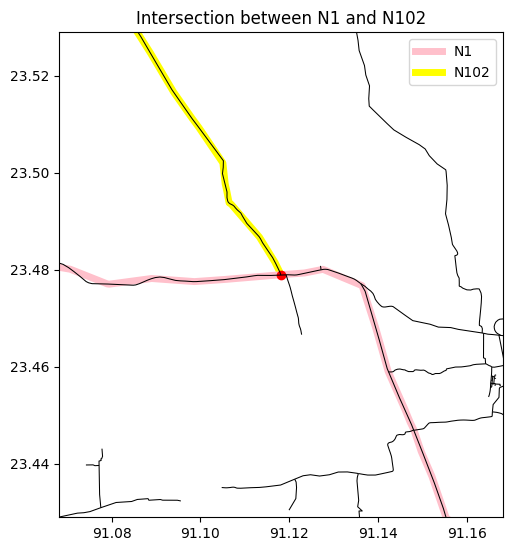

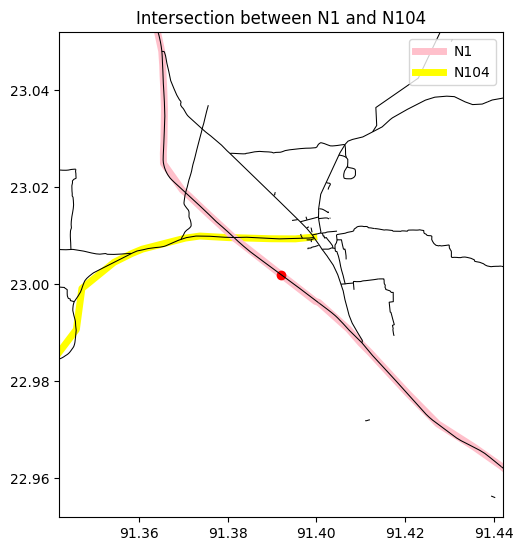

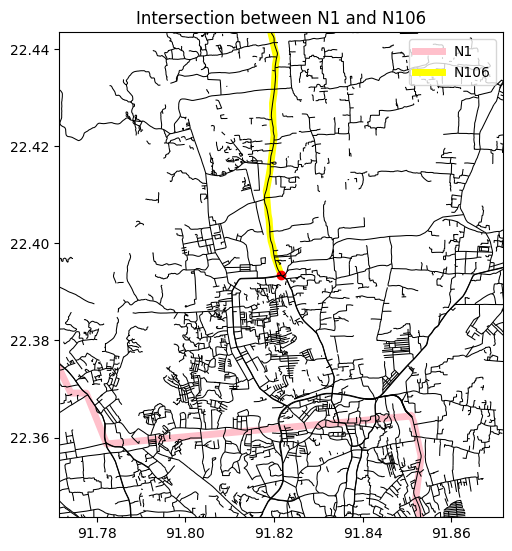

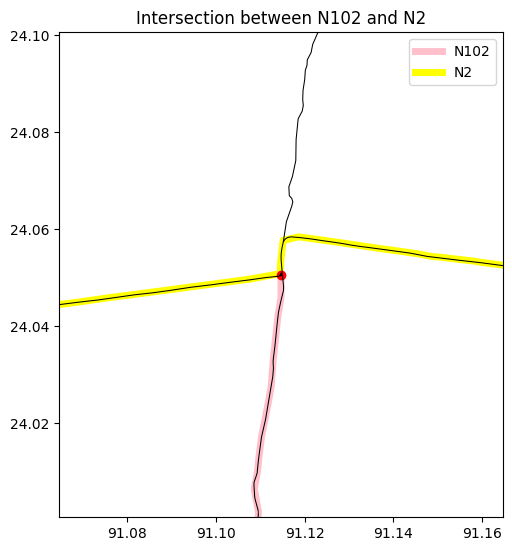

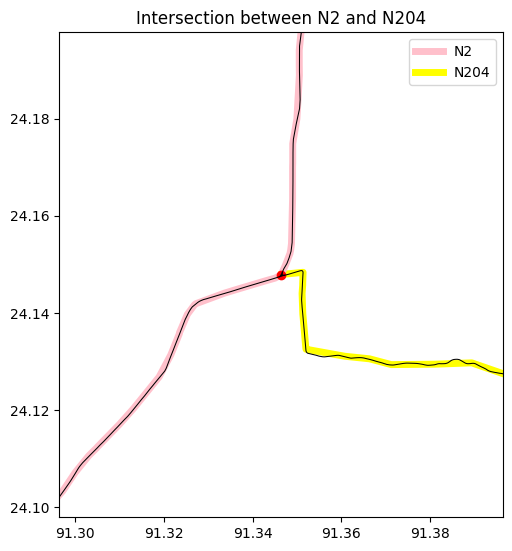

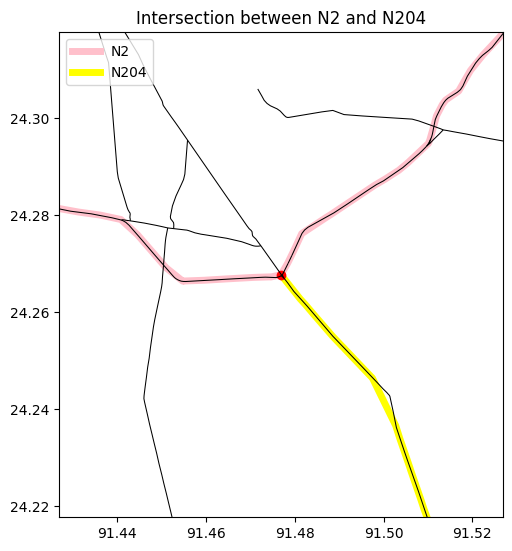

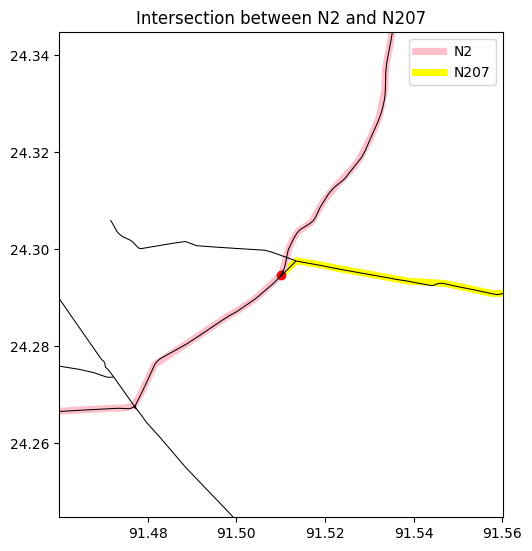

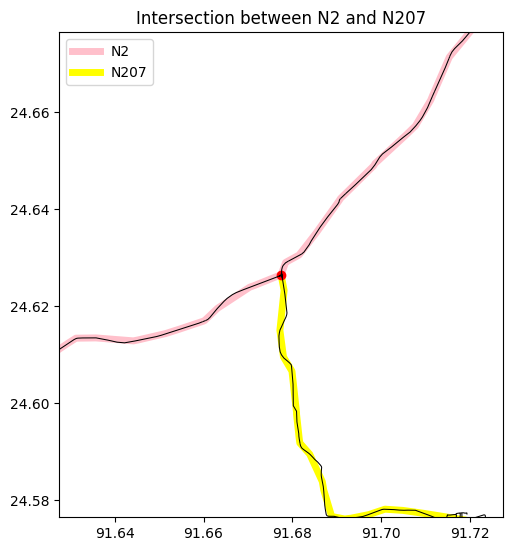

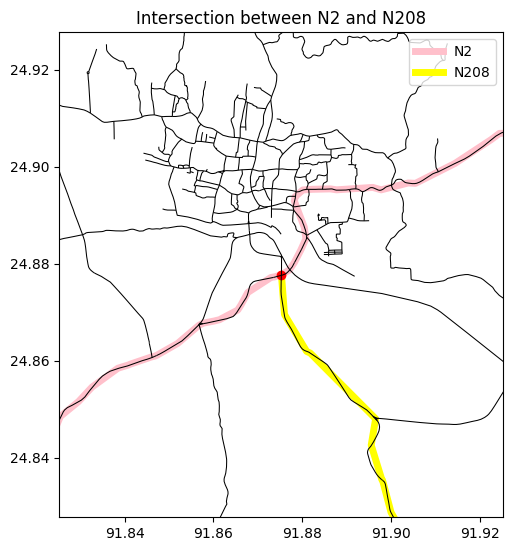

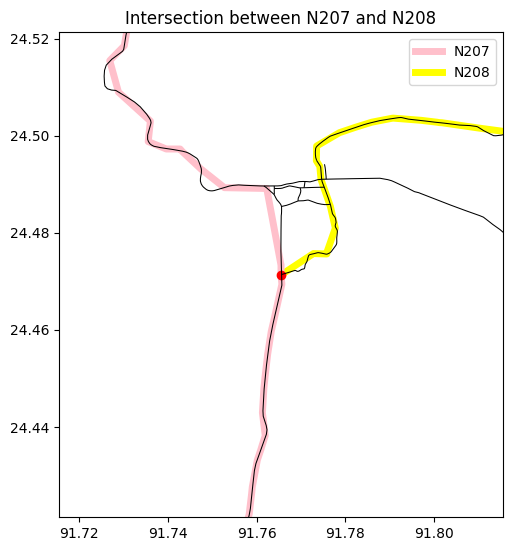

In [11]:
#Next, the intersections are plotted on top of the shapefile
shown_maps = []
for i in inter.index:
    if inter.loc[i,'intersect'] and inter.loc[i,'id'] not in shown_maps:
        intersect_road = inter[inter.id == inter.loc[i,'intersect']].reset_index().road[0]
        id_road = inter.loc[i,'road']

        fig, ax = plt.subplots(figsize = (5.9,6.3))
        plt.title(f'Intersection between {id_road} and {intersect_road}')

        #The roads from the roads csv file are also plotted, to clearly show which of the roads in the shapefile are the roads of the intersection
        plt.plot(roads[roads.road==id_road].lon, roads[roads.road==id_road].lat, color = 'pink', label = id_road, linewidth = 5, zorder = 1)
        plt.plot(roads[roads.road==intersect_road].lon, roads[roads.road==intersect_road].lat, color = 'yellow', label = intersect_road, linewidth = 5, zorder = 0)

        shown_maps.append(inter.loc[i,'intersect'])         #to not show intersections double
        shown_maps.append(inter.loc[i,'id'])

        plt.scatter(inter.loc[i,'lon'], inter.loc[i,'lat'], c = 'red', zorder = 2)
        gdf.plot(ax = ax, linewidth = 0.75, color = 'black', zorder = 3)

        #The plot is zoomed in to clearly show the relevant intersection
        ax.set_xlim(inter.loc[i,'lon']-0.05, inter.loc[i,'lon']+0.05)
        ax.set_ylim(inter.loc[i,'lat']-0.05, inter.loc[i,'lat']+0.05)
        plt.savefig(f'../../img/intersection_viz/Intersection_between_{id_road}_and_{intersect_road}.png')
        plt.legend()
        plt.show()

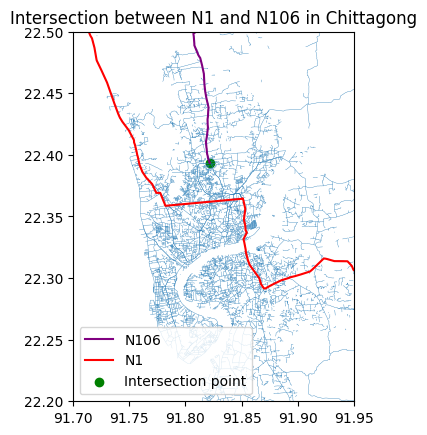

In [12]:
#To explain why the intersection between N1 and N106 is inaccurate, this intersection is shown more zoomed out
fig, ax = plt.subplots()
plt.title('Intersection between N1 and N106 in Chittagong')
gdf.plot(ax = ax, linewidth = 0.25)

plt.plot(roads[roads.road=='N106'].lon,roads[roads.road=='N106'].lat, color = 'purple', label = 'N106')
plt.plot(roads[roads.road=='N1'].lon,roads[roads.road=='N1'].lat, color = 'red', label = 'N1')

plt.scatter(inter.loc[9,'lon'], inter.loc[9,'lat'], c = 'green', label = 'Intersection point')

ax.set_xlim(91.7, 91.95)
ax.set_ylim(22.2,22.5)

plt.legend()
plt.show()